In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils_simplagion_on_RSC import *
import copy

In [2]:
# ============================================================================
# 参数设置
# ============================================================================
N = 2000
k1 = 20
k2 = 6
mu = 0.05
t_max = 500

# 固定 λ 和 λ_Δ（双稳态区域内）
lambda_target = 0.75
lambdaD_target = 2.5

# 不同初始感染密度 ρ₀ (%)
rho0_list = np.linspace(0, 1, 19) 

# 生成网络（固定，所有 ρ₀ 共用）
p1, p2 = get_p1_and_p2(k1, k2, N)
node_neighbors_dict, triangles_list = generate_my_simplicial_complex_d2(N, p1, p2)

# 计算实际平均度
real_k = sum(len(v) for v in node_neighbors_dict.values()) / len(node_neighbors_dict)
real_kD = 3 * len(triangles_list) / len(node_neighbors_dict)

# 计算 β 值
beta1 = lambda_target * mu / real_k
beta2 = lambdaD_target * mu / real_kD

print(f"Network: k={real_k:.1f}, kΔ={real_kD:.1f}")
print(f"β1={beta1:.5f}, β2={beta2:.5f}")

not connected, but GC has order 1999 ans size 7985
Network: k=20.2, kΔ=6.1
β1=0.00186, β2=0.02039


In [3]:
def rho_minus(lam, lamD):
    if lamD <= 0:
        return np.nan
    disc = (lam - lamD)**2 - 4*lamD*(1 - lam)
    if disc < 0:
        return np.nan
    val = (lamD - lam - np.sqrt(disc)) / (2*lamD)
    return val if 0 < val < 1 else np.nan

rho_minus_theory = rho_minus(lambda_target, lambdaD_target)
print(f"ρ₂₋* (theory) = {rho_minus_theory:.4f}")

ρ₂₋* (theory) = 0.2000


Running ρ₀ = 0.000 ...
Running ρ₀ = 0.056 ...
Running ρ₀ = 0.111 ...
Running ρ₀ = 0.167 ...
Running ρ₀ = 0.222 ...
Running ρ₀ = 0.278 ...
Running ρ₀ = 0.333 ...
Running ρ₀ = 0.389 ...
Running ρ₀ = 0.444 ...
Running ρ₀ = 0.500 ...
Running ρ₀ = 0.556 ...
Running ρ₀ = 0.611 ...
Running ρ₀ = 0.667 ...
Running ρ₀ = 0.722 ...
Running ρ₀ = 0.778 ...
Running ρ₀ = 0.833 ...
Running ρ₀ = 0.889 ...
Running ρ₀ = 0.944 ...
Running ρ₀ = 1.000 ...


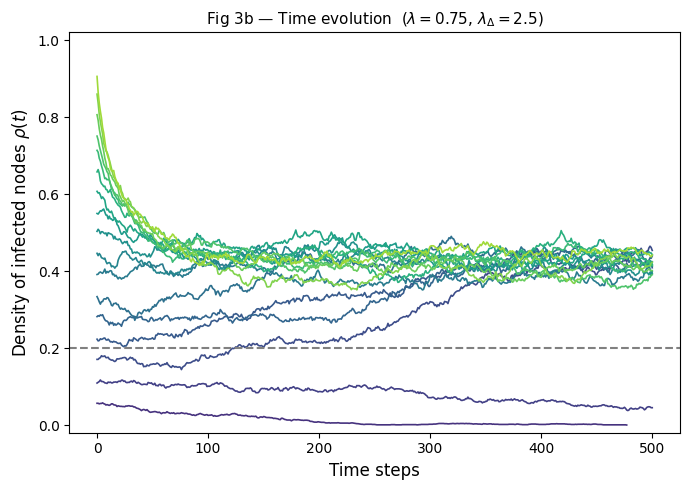

In [4]:
# ============================================================================
# 对每个 ρ₀ 跑一次模拟，记录时间序列
# ============================================================================
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(rho0_list)))

fig, ax = plt.subplots(figsize=(7, 5))

for idx, rho0 in enumerate(rho0_list):
    print(f"Running ρ₀ = {rho0:.3f} ...")
    
    # 注意：SimplagionModel 的第三个参数是 I_percentage（百分比）
    # 所以需要把 ρ₀（0-1）转换成百分比（0-100）
    rho0_percent = rho0 * 100
    
    # 创建模型
    model = SimplagionModel(node_neighbors_dict, triangles_list, rho0_percent)
    
    # 跑模拟，返回 iList（每个时间步的感染人数）
    iList = model.run(t_max, beta1, beta2, mu, print_status=False)
    
    # 转换为密度
    rho_history = np.array(iList) / N
    
    # 画图
    ax.plot(range(len(rho_history)), rho_history, '-', color=colors[idx], lw=1.2,
            label=f'$\\rho_0 = {rho0:.2f}$')
    

# 添加理论虚线
ax.axhline(y=rho_minus_theory, color='gray', linestyle='--', lw=1.5,
           label=f'$\\rho_{{2-}}^*$ (MF)')

ax.set_xlabel('Time steps', fontsize=12)
ax.set_ylabel(r'Density of infected nodes $\rho(t)$', fontsize=12)
ax.set_title(f'Fig 3b — Time evolution  ($\\lambda={lambda_target}$, $\\lambda_\\Delta={lambdaD_target}$)', fontsize=11)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig('fig3b_time_evolution_1.png', dpi=150)
plt.show()